<a href="https://colab.research.google.com/github/mehaksingh0210/website-traffic-analysis/blob/main/website_traffic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('website-traffic.dataset.csv')

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,21-08-2021,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,21-08-2021,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,21-08-2021,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,21-08-2021,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,21-08-2021,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [4]:
df.columns
df.shape
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df['date'] = pd.to_datetime(df['date'])

In [13]:
df['country'] = df['country'].fillna('Unknown')
df['city'] = df['city'].fillna('Unknown')
df['artist'] = df['artist'].fillna('Unknown')
df['album'] = df['album'].fillna('Unknown')
df['track'] = df['track'].fillna('Unknown')

In [14]:
total_events = len(df)

print("Total Events:", total_events)

Total Events: 122567


In [15]:
print(df['country'].nunique())

212


In [16]:
print(df['city'].nunique())
print(df['artist'].nunique())
print(df['track'].nunique())

11993
2420
3563


In [17]:
df['event'].value_counts()

,count
event,
pageview,73360
click,32499
preview,16708


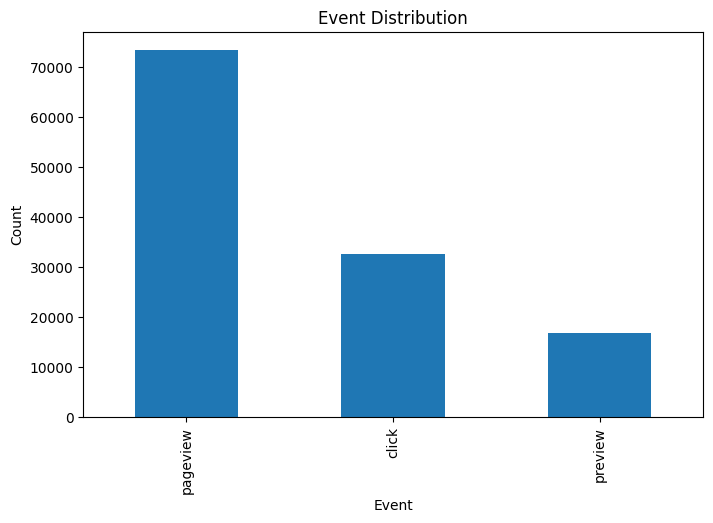

In [19]:
import matplotlib.pyplot as plt

df['event'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Event Distribution")
plt.xlabel("Event")
plt.ylabel("Count")
plt.show()

In [20]:
top_country = df['country'].value_counts().head(10)

top_country

,count
country,
United States,28664
India,18689
France,10565
Saudi Arabia,7682
United Kingdom,5095
Germany,4017
Canada,2784
Pakistan,2633
Iraq,2444


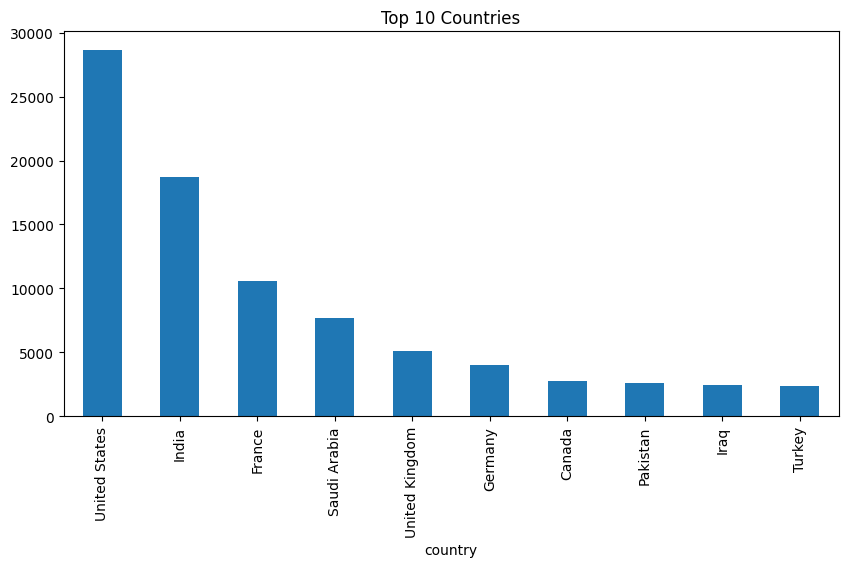

In [21]:
top_country.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Countries")
plt.show()

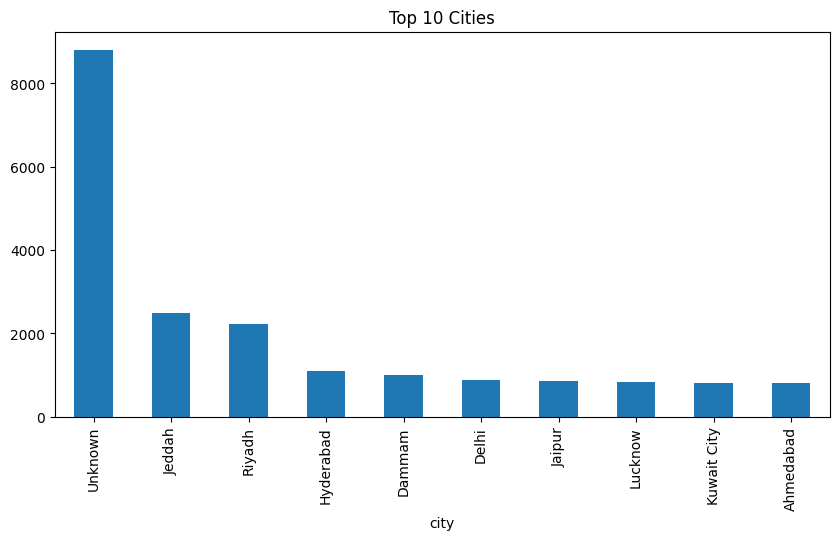

In [22]:
top_city = df['city'].value_counts().head(10)

top_city.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Cities")
plt.show()

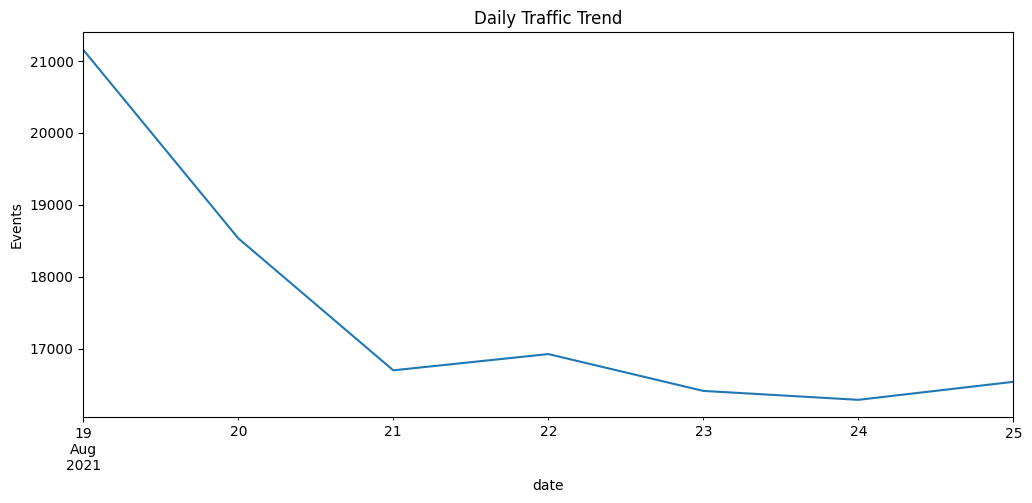

In [24]:
daily_traffic = df.groupby('date').size()
daily_traffic.plot(
    figsize=(12,5)
)

plt.title("Daily Traffic Trend")
plt.ylabel("Events")
plt.show()

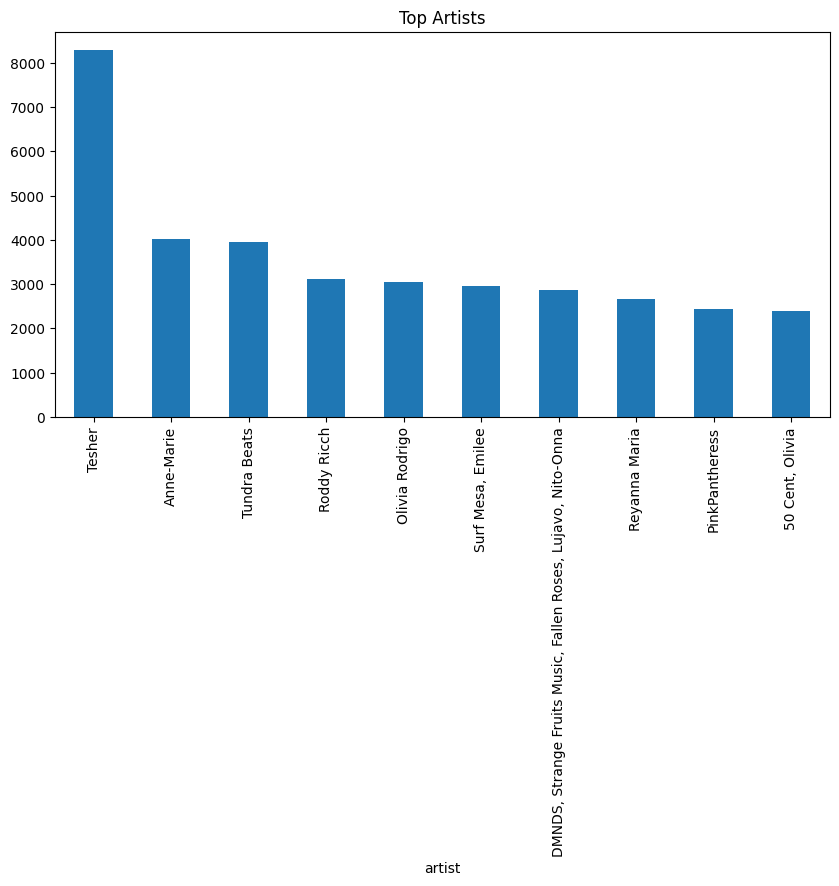

In [25]:
top_artist = df['artist'].value_counts().head(10)

top_artist

top_artist.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Artists")
plt.show()

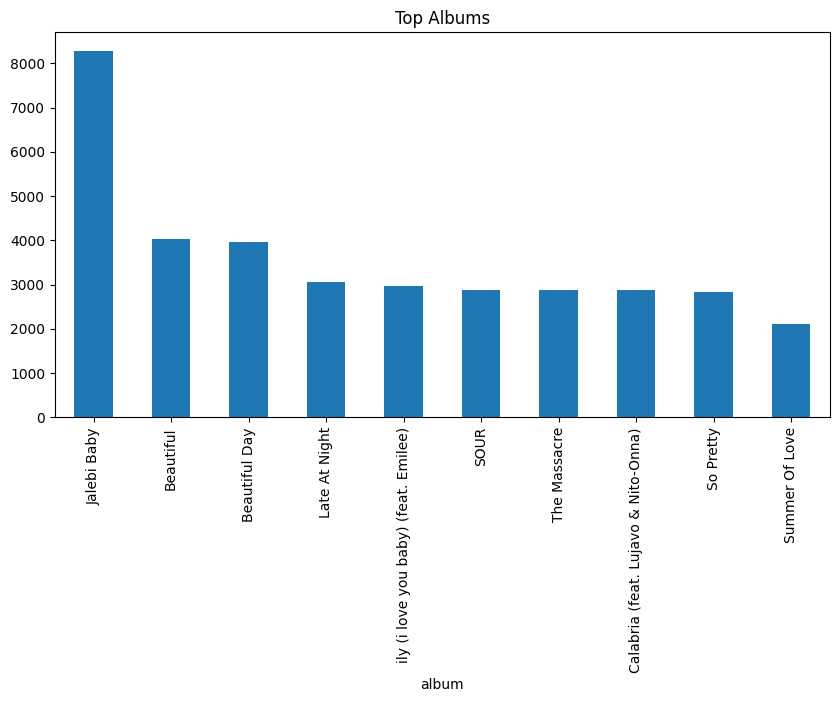

In [26]:
top_album = df['album'].value_counts().head(10)

top_album.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Albums")
plt.show()

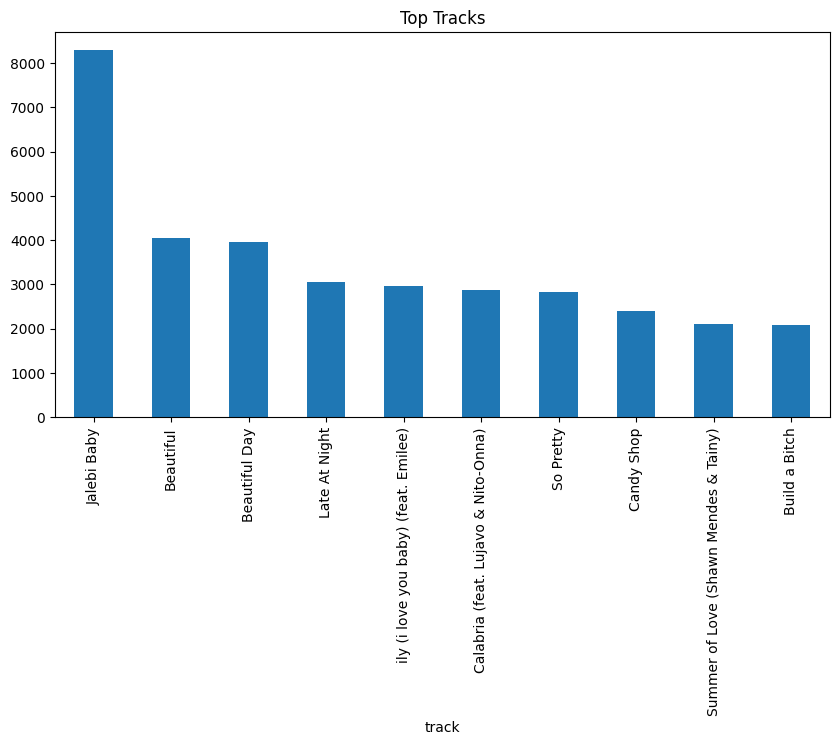

In [27]:
top_track = df['track'].value_counts().head(10)

top_track.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Tracks")
plt.show()

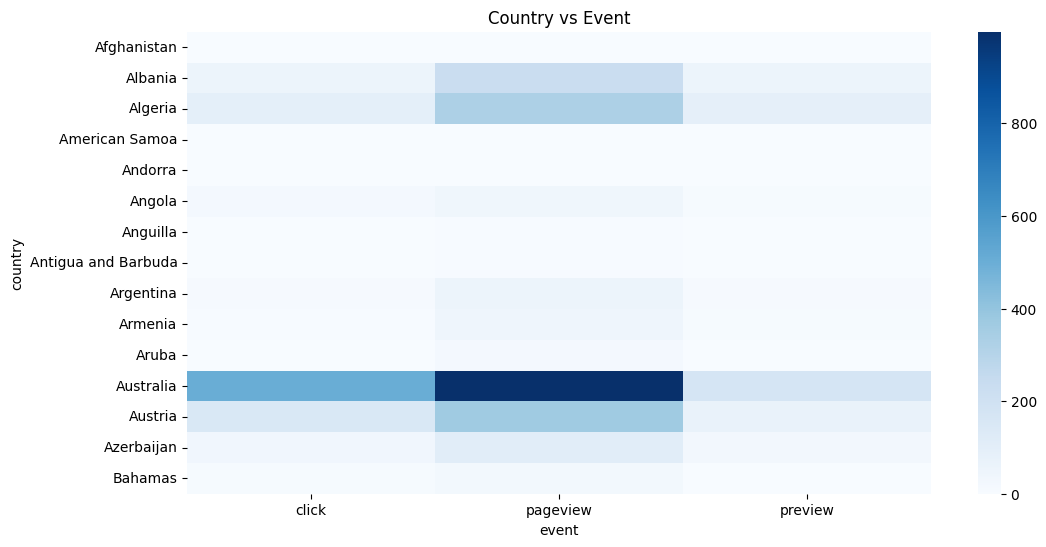

In [28]:
import seaborn as sns

country_event = pd.crosstab(
    df['country'],
    df['event']
).head(15)

plt.figure(figsize=(12,6))

sns.heatmap(
    country_event,
    cmap='Blues'
)

plt.title("Country vs Event")
plt.show()

In [30]:
df['month'] = df['date'].dt.to_period('M')

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


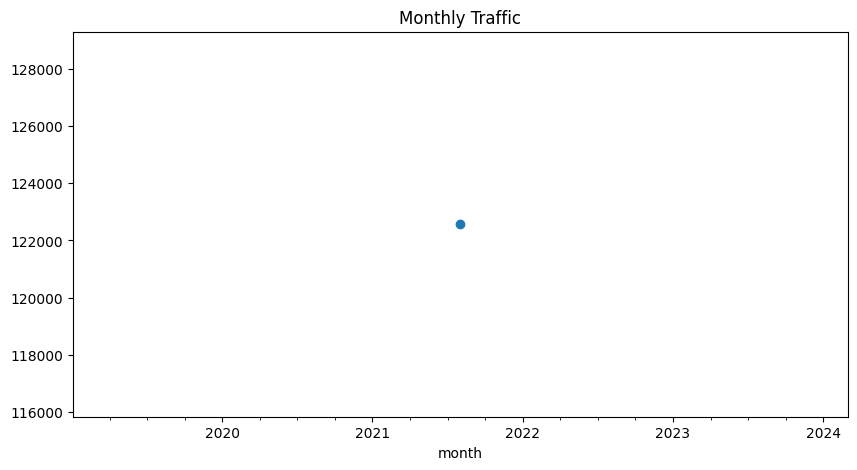

In [31]:
monthly = df.groupby('month').size()

monthly.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Monthly Traffic")
plt.show()

In [32]:
top_links = df['linkid'].value_counts().head(10)

top_links

,count
linkid,
2d896d31-97b6-4869-967b-1c5fb9cd4bb8,8288
e849515b-929d-44c8-a505-e7622f1827e9,3950
522da5cc-8177-4140-97a7-a84fdb4caf1c,3786
a82e72d8-523f-43ab-9fd0-992605d54b4e,3059
681d888a-59ce-4acb-b7c5-95dab0c063d9,2865
23199824-9cf5-4b98-942a-34965c3b0cc2,2675
c2c876ab-b093-4750-9449-6b4913da6af3,2442
97105aff-3e40-4c2e-bfeb-563b55e8f5dd,2390
d5317591-872a-487d-87cb-10a516643d5f,2074


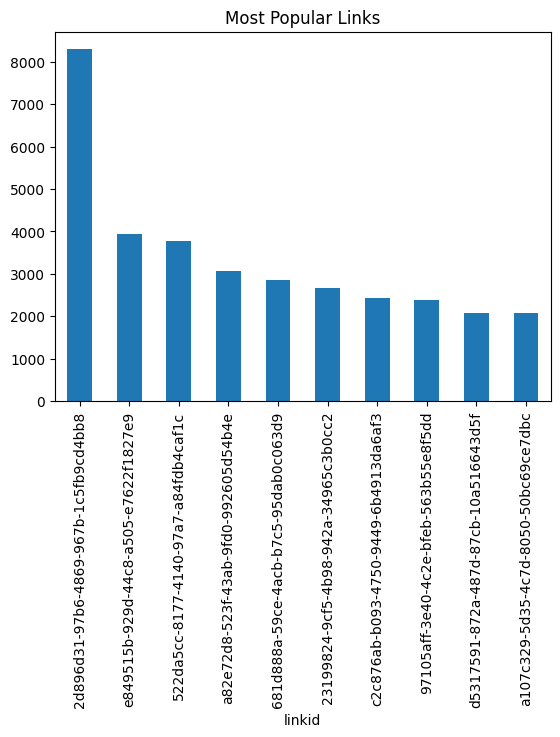

In [33]:
top_links.plot(
    kind='bar'
)

plt.title("Most Popular Links")
plt.show()

In [34]:
kpi = pd.DataFrame({
    "Metric":[
        "Total Events",
        "Countries",
        "Cities",
        "Artists",
        "Tracks"
    ],
    "Value":[
        len(df),
        df['country'].nunique(),
        df['city'].nunique(),
        df['artist'].nunique(),
        df['track'].nunique()
    ]
})

print(kpi)

         Metric   Value
0  Total Events  122567
1     Countries     212
2        Cities   11993
3       Artists    2420
4        Tracks    3563


In [36]:
event_flow = df['event'].value_counts().reset_index()
event_flow.columns = ['Event','Count']

print(event_flow)

      Event  Count
0  pageview  73360
1     click  32499
2   preview  16708
